In [ ]:
# Uncomment to install if needed
# !pip install pandas numpy scikit-learn imbalanced-learn xgboost matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, recall_score, precision_score, f1_score, roc_curve
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

In [ ]:
df=pd.read_excel("/content/Telco_customer_churn.xlsx")

In [ ]:
print("Data Types")
print(df.dtypes)

Data Types
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object


In [ ]:
#Data Cleaning
df.sample(10)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
257,1989-PRJHP,1,United States,California,Pleasanton,94588,"37.685052, -121.912061",37.685052,-121.912061,Male,...,Month-to-month,Yes,Electronic check,75.50,1893.95,Yes,1,65,2377,Competitor had better devices
5961,8838-GPHZP,1,United States,California,Orange,92866,"33.784597, -117.844535",33.784597,-117.844535,Female,...,Two year,Yes,Mailed check,20.60,1298.7,No,0,23,6469,NaN
737,4831-EOBFE,1,United States,California,Mountain Ranch,95246,"38.264262, -120.515133",38.264262,-120.515133,Male,...,Month-to-month,No,Credit card (automatic),94.65,2649.15,Yes,1,70,5150,Don't know
3978,0233-FTHAV,1,United States,California,Livingston,95334,"37.361987, -120.748394",37.361987,-120.748394,Female,...,One year,Yes,Bank transfer (automatic),79.20,4765,No,0,49,5687,NaN
5722,5336-UFNZP,1,United States,California,Monterey Park,91755,"34.049172, -118.115022",34.049172,-118.115022,Female,...,One year,Yes,Electronic check,107.45,7047.5,No,0,32,6211,NaN
354,2845-HSJCY,1,United States,California,Whitethorn,95589,"40.053159, -123.995867",40.053159,-123.995867,Female,...,Month-to-month,Yes,Electronic check,87.25,1258.6,Yes,1,78,4786,Competitor offered higher download speeds
141,0939-YAPAF,1,United States,California,Santa Ana,92701,"33.748478, -117.858918",33.748478,-117.858918,Female,...,Month-to-month,Yes,Electronic check,100.25,3527.6,Yes,1,72,2744,Competitor offered higher download speeds
5351,5176-OLSKT,1,United States,California,Sloughhouse,95683,"38.470423, -121.114897",38.470423,-121.114897,Female,...,Two year,No,Bank transfer (automatic),66.90,4370.25,No,0,61,5546,NaN
2975,5724-BIDBU,1,United States,California,Penn Valley,95946,"39.203817, -121.19584",39.203817,-121.195840,Male,...,One year,Yes,Electronic check,55.35,2633.95,No,0,26,5601,NaN
3390,3392-EHMNK,1,United States,California,Thermal,92274,"33.53604, -116.119222",33.536040,-116.119222,Female,...,Two year,No,Credit card (automatic),94.10,6302.8,No,0,58,4803,NaN


In [ ]:
print(df.isnull().sum())

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


In [ ]:
print("=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

# TotalCharges may be stored as string — convert to numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Drop rows with missing TotalCharges (usually ~11 rows with tenure=0)
missing_before = len(df)
df.dropna(subset=['Total Charges'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nDropped {missing_before - len(df)} rows with missing Total Charges")
print(f"Final dataset shape: {df.shape}")

# Churn Label: Yes=1, No=0
df['Churn'] = (df['Churn Label'] == 'Yes').astype(int)

print(f"\nChurn Distribution:")
print(df['Churn Label'].value_counts())

=== Missing Values ===
Churn Reason    5174
dtype: int64

Dropped 11 rows with missing Total Charges
Final dataset shape: (7032, 33)

Churn Distribution:
Churn Label
No     5163
Yes    1869
Name: count, dtype: int64


In [ ]:
df.sample(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Churn
5773,9700-ISPUP,1,United States,California,Valley Center,92082,"33.25283, -116.986079",33.252830,-116.986079,Female,...,Yes,Electronic check,65.50,616.90,No,0,44,3137,NaN,0
5153,7611-YKYTC,1,United States,California,Burson,95225,"38.183918, -120.898817",38.183918,-120.898817,Male,...,No,Bank transfer (automatic),75.00,1573.95,No,0,48,4040,NaN,0
6931,9609-BENEA,1,United States,California,Chula Vista,91914,"32.688506, -116.938632",32.688506,-116.938632,Male,...,Yes,Electronic check,69.00,2441.70,No,0,59,5283,NaN,0
1464,0013-EXCHZ,1,United States,California,Camarillo,93010,"34.227846, -119.079903",34.227846,-119.079903,Female,...,Yes,Mailed check,83.90,267.40,Yes,1,68,3464,Network reliability,1
6460,6128-DAFVY,1,United States,California,Willits,95490,"39.492046, -123.375818",39.492046,-123.375818,Female,...,Yes,Credit card (automatic),44.85,2564.95,No,0,27,4021,NaN,0


In [ ]:
#EDA

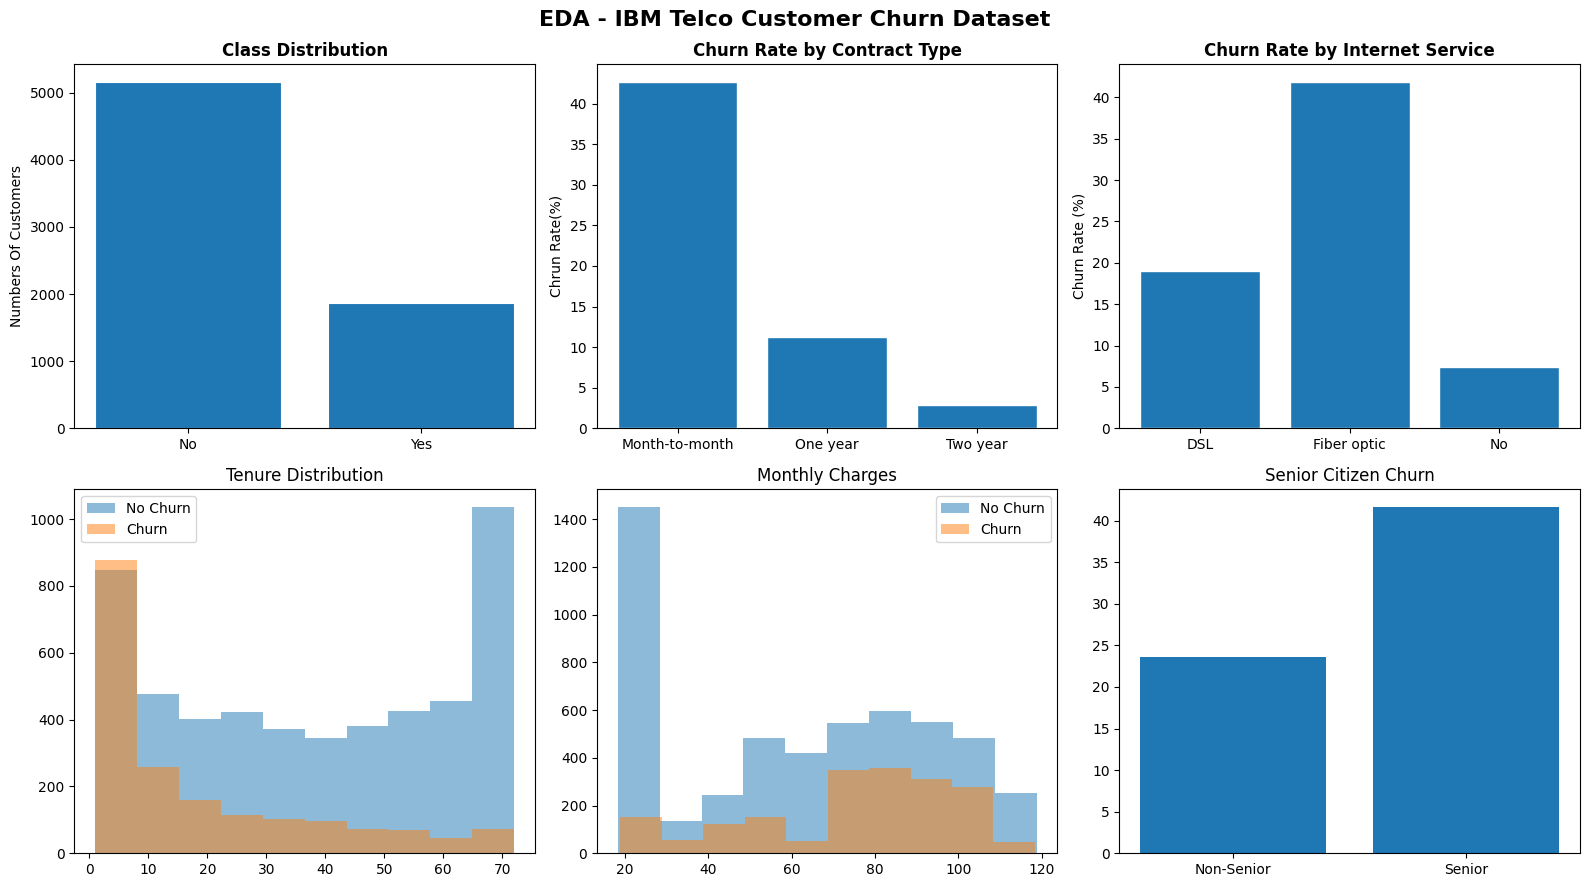

In [ ]:
fig, axes=plt.subplots(2,3,figsize=(16,9))
fig.suptitle('EDA - IBM Telco Customer Churn Dataset',fontsize=16,fontweight='bold')
#1. Class Distribution
counts=df['Churn Label'].value_counts()
axes[0,0].bar(counts.index,counts.values,edgecolor='white',linewidth=0.8)
axes[0,0].set_title('Class Distribution',fontweight='bold')
axes[0,0].set_ylabel('Numbers Of Customers')

#2. Churn by contract
cts= df.groupby('Contract')['Churn'].mean()*100
axes[0,1].bar(cts.index,cts.values,edgecolor='white')
axes[0,1].set_title('Churn Rate by Contract Type',fontweight='bold')
axes[0,1].set_ylabel('Chrun Rate(%)')

#3. Churn by Internet Service
ci = df.groupby('Internet Service')['Churn'].mean() * 100
axes[0,2].bar(ci.index, ci.values, edgecolor='white')
axes[0,2].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[0,2].set_ylabel('Churn Rate (%)')

#4 Chrun By Tenure
axes[1,0].hist(df[df['Churn']==0]['Tenure Months'], alpha=0.5, label='No Churn')
axes[1,0].hist(df[df['Churn']==1]['Tenure Months'], alpha=0.5, label='Churn')
axes[1,0].set_title("Tenure Distribution")
axes[1,0].legend()

#5. Monthy Charges
axes[1,1].hist(df[df['Churn']==0]['Monthly Charges'], alpha=0.5, label='No Churn')
axes[1,1].hist(df[df['Churn']==1]['Monthly Charges'], alpha=0.5, label='Churn')
axes[1,1].set_title("Monthly Charges")
axes[1,1].legend()

#6. Churn by Senior Citizens
senior = df.groupby('Senior Citizen')['Churn'].mean() * 100
axes[1,2].bar(['Non-Senior', 'Senior'], senior.values)
axes[1,2].set_title("Senior Citizen Churn")

plt.tight_layout()
plt.savefig("eda_plots.png")
plt.show()

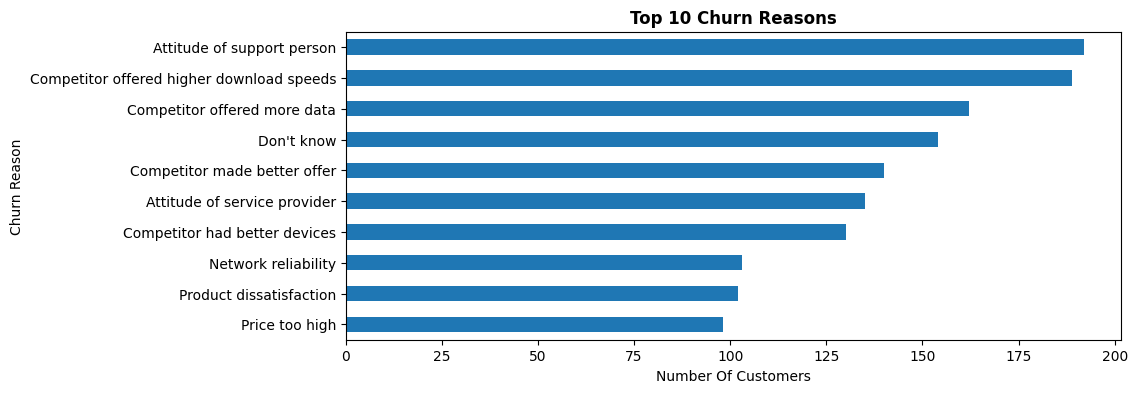

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64


In [ ]:

#Top 10 Churn Reasons
if 'Churn Reason' in df.columns:
    top_reasons= (df[df['Churn']==1]['Churn Reason'].value_counts().head(10))
    plt.figure(figsize=(10,4))
    top_reasons[::-1].plot(kind='barh')
    plt.title('Top 10 Churn Reasons',fontweight='bold')
    plt.xlabel('Number Of Customers')
    plt.show()
    print(top_reasons)


In [ ]:
# ── Columns to use as features ────────────────────────────────
# Drop ID, target duplicates, and IBM-specific score columns
DROP_COLS = [
    'CustomerID', 'Churn Label', 'Churn Value', 'Churn Score',
    'CLTV', 'Churn Reason', 'Churn',   # will add Churn back as target
    'Count', 'Country', 'State', 'City', 'Zip Code',
    'Lat Long', 'Latitude', 'Longitude'
]
# Only drop columns that actually exist
drop_existing = [c for c in DROP_COLS if c in df.columns]
feature_df = df.drop(columns=drop_existing)

print(f"Features after dropping IDs/targets: {list(feature_df.columns)}")
print(f"Number of features: {len(feature_df.columns)}")


Features after dropping IDs/targets: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']
Number of features: 19


In [ ]:
# ── Label Encode categorical columns ─────────────────────────
df_enc = feature_df.copy()
label_encoders = {}

cat_cols = df_enc.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode ({len(cat_cols)}):")

for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    label_encoders[col] = le
    print(f"  {col:<30} → classes: {list(le.classes_)[:4]}{'...' if len(le.classes_)>4 else ''}")

X = df_enc.values
y = df['Churn'].values
feature_cols = df_enc.columns.tolist()

print(f"\nFeature matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")

Categorical columns to encode (16):
  Gender                         → classes: ['Female', 'Male']
  Senior Citizen                 → classes: ['No', 'Yes']
  Partner                        → classes: ['No', 'Yes']
  Dependents                     → classes: ['No', 'Yes']
  Phone Service                  → classes: ['No', 'Yes']
  Multiple Lines                 → classes: ['No', 'No phone service', 'Yes']
  Internet Service               → classes: ['DSL', 'Fiber optic', 'No']
  Online Security                → classes: ['No', 'No internet service', 'Yes']
  Online Backup                  → classes: ['No', 'No internet service', 'Yes']
  Device Protection              → classes: ['No', 'No internet service', 'Yes']
  Tech Support                   → classes: ['No', 'No internet service', 'Yes']
  Streaming TV                   → classes: ['No', 'No internet service', 'Yes']
  Streaming Movies               → classes: ['No', 'No internet service', 'Yes']
  Contract                      

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train : {X_train.shape}  |  Churn rate: {y_train.mean():.2%}")
print(f"X_test  : {X_test.shape}   |  Churn rate: {y_test.mean():.2%}")


X_train : (5625, 19)  |  Churn rate: 26.58%
X_test  : (1407, 19)   |  Churn rate: 26.58%


Before SMOTE: 5625 samples | Churn: 26.58%
After  SMOTE: 8260 samples | Churn: 50.00% ← balanced!


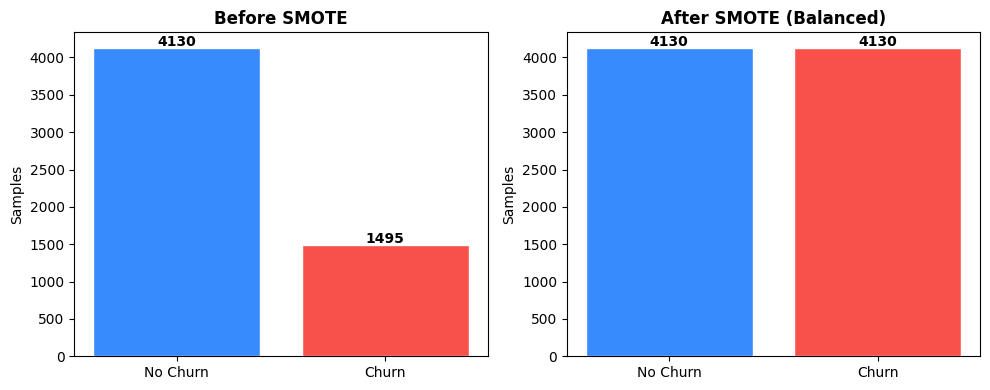

In [ ]:
print(f"Before SMOTE: {len(y_train)} samples | Churn: {y_train.mean():.2%}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After  SMOTE: {len(y_train_res)} samples | Churn: {y_train_res.mean():.2%} ← balanced!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title in zip(axes,
    [(y_train==0).sum(), (y_train==1).sum()],
    ['Before SMOTE', 'After SMOTE (Balanced)']):
    pass  # placeholder

before = [(y_train==0).sum(), (y_train==1).sum()]
after  = [(y_train_res==0).sum(), (y_train_res==1).sum()]
for ax, vals, title in zip(axes, [before, after],
                            ['Before SMOTE', 'After SMOTE (Balanced)']):
    ax.bar(['No Churn','Churn'], vals, color=['#388bfd','#f85149'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Samples')
    for i, v in enumerate(vals):
        ax.text(i, v+20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

models_cfg = {
    'Logistic Regression': {
        'model' : LogisticRegression(C=1, max_iter=1000, random_state=42),
        'scaled': True
    },
    'Random Forest': {
        'model' : RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
        'scaled': False
    },
    'XGBoost': {
        'model' : xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            scale_pos_weight=3,
            use_label_encoder=False, eval_metric='logloss', random_state=42
        ),
        'scaled': False
    }
}

results = {}
print(f"{'Model':<25} {'Recall':>8} {'Precision':>10} {'F1':>8} {'AUC':>8}")
print("-" * 63)

for name, cfg in models_cfg.items():
    m = cfg['model']
    if cfg['scaled']:
        m.fit(X_train_sc, y_train_res)
        probs = m.predict_proba(X_test_sc)[:, 1]
    else:
        m.fit(X_train_res, y_train_res)
        probs = m.predict_proba(X_test)[:, 1]

    preds = (probs >= 0.5).astype(int)
    results[name] = {
        'model': m, 'probs': probs, 'preds': preds, 'scaled': cfg['scaled'],
        'recall':    recall_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'f1':        f1_score(y_test, preds),
        'auc':       roc_auc_score(y_test, probs),
    }
    print(f"{name:<25} {results[name]['recall']:>8.4f} "
          f"{results[name]['precision']:>10.4f} "
          f"{results[name]['f1']:>8.4f} "
          f"{results[name]['auc']:>8.4f}")


Model                       Recall  Precision       F1      AUC
---------------------------------------------------------------
Logistic Regression         0.7807     0.5052   0.6134   0.8410
Random Forest               0.6765     0.5573   0.6111   0.8393
XGBoost                     0.7968     0.5201   0.6294   0.8361


Optimal Threshold : 0.10
Best Recall       : 0.9519


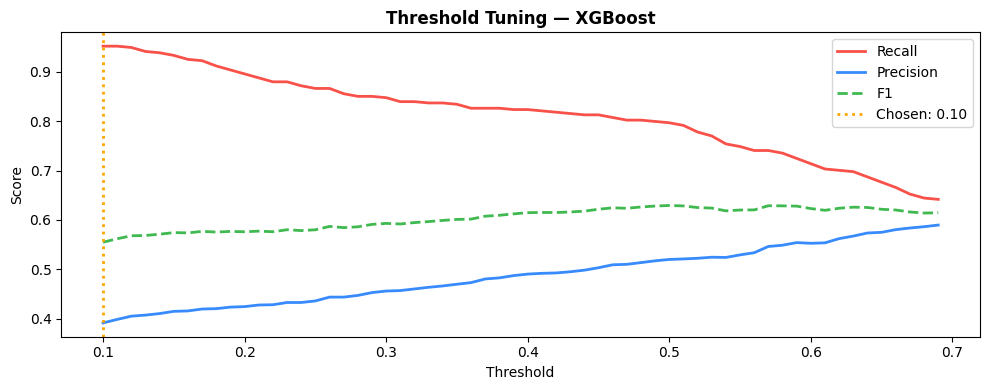

In [ ]:
xgb_probs = results['XGBoost']['probs']
thresh_records = []
best_thresh, best_recall = 0.5, 0.0

for t in np.arange(0.10, 0.70, 0.01):
    preds = (xgb_probs >= t).astype(int)
    rec   = recall_score(y_test, preds)
    prec  = precision_score(y_test, preds)
    f1    = f1_score(y_test, preds)
    thresh_records.append({'threshold': round(t,2), 'recall': rec,
                            'precision': prec, 'f1': f1})
    if prec > 0.25 and rec > best_recall:
        best_recall = rec
        best_thresh = t

df_thresh = pd.DataFrame(thresh_records)
print(f"Optimal Threshold : {best_thresh:.2f}")
print(f"Best Recall       : {best_recall:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(df_thresh['threshold'], df_thresh['recall'],    color='#f85149', lw=2, label='Recall')
plt.plot(df_thresh['threshold'], df_thresh['precision'], color='#388bfd', lw=2, label='Precision')
plt.plot(df_thresh['threshold'], df_thresh['f1'],        color='#3fb950', lw=2, ls='--', label='F1')
plt.axvline(best_thresh, color='orange', lw=2, ls=':', label=f'Chosen: {best_thresh:.2f}')
plt.title('Threshold Tuning — XGBoost', fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
y_pred_opt = (xgb_probs >= best_thresh).astype(int)

print("=" * 55)
print(f"XGBoost — Threshold = {best_thresh:.2f}")
print("=" * 55)
print(f"Recall    : {recall_score(y_test, y_pred_opt):.4f}  ← PRIMARY METRIC")
print(f"Precision : {precision_score(y_test, y_pred_opt):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_opt):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, xgb_probs):.4f}")
print()
print(classification_report(y_test, y_pred_opt,
                            target_names=['Stay (No)', 'Churn (Yes)']))


XGBoost — Threshold = 0.10
Recall    : 0.9519  ← PRIMARY METRIC
Precision : 0.3916
F1 Score  : 0.5549
AUC-ROC   : 0.8361

              precision    recall  f1-score   support

   Stay (No)       0.96      0.46      0.63      1033
 Churn (Yes)       0.39      0.95      0.55       374

    accuracy                           0.59      1407
   macro avg       0.68      0.71      0.59      1407
weighted avg       0.81      0.59      0.61      1407



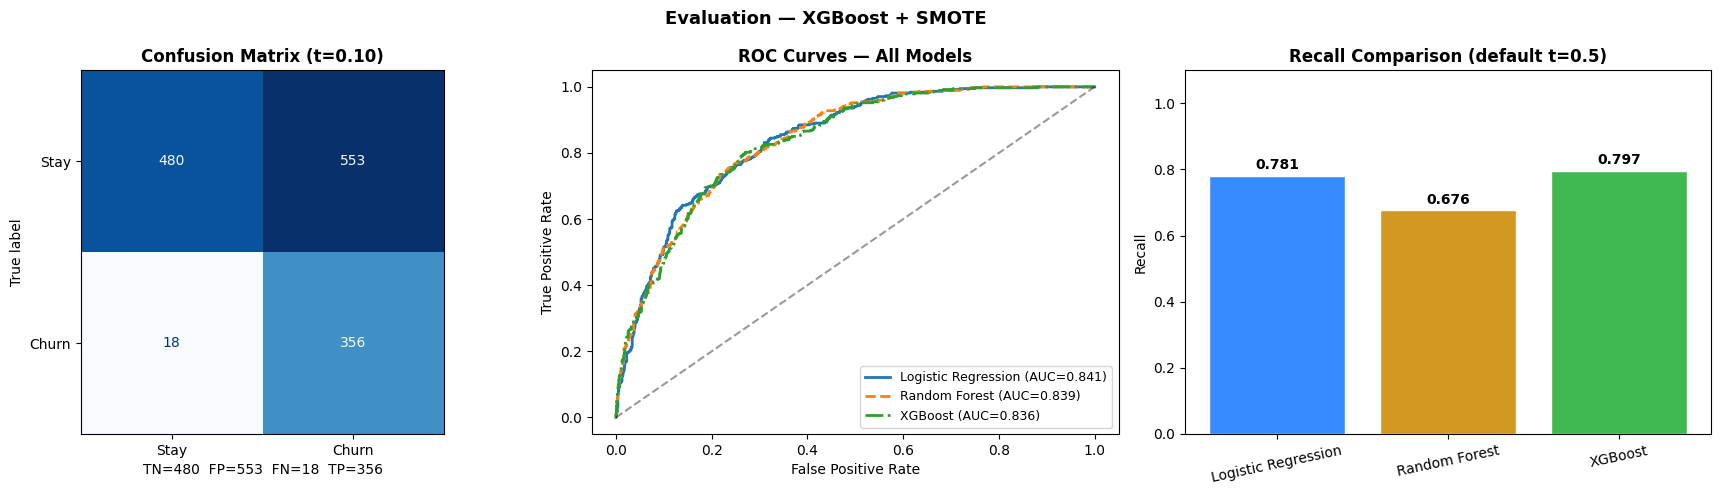

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evaluation — XGBoost + SMOTE', fontsize=13, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm, display_labels=['Stay','Churn']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
tn, fp, fn, tp = cm.ravel()
axes[0].set_title(f'Confusion Matrix (t={best_thresh:.2f})', fontweight='bold')
axes[0].set_xlabel(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

# ROC Curves
for (name, r), ls in zip(results.items(), ['-','--','-.']):
    fpr, tpr, _ = roc_curve(y_test, r['probs'])
    axes[1].plot(fpr, tpr, lw=2, ls=ls, label=f"{name} (AUC={r['auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

# Recall Comparison
names   = list(results.keys())
recalls = [results[n]['recall'] for n in names]
bars = axes[2].bar(names, recalls, color=['#388bfd','#d29922','#3fb950'], edgecolor='white')
axes[2].set_title('Recall Comparison (default t=0.5)', fontweight='bold')
axes[2].set_ylabel('Recall')
axes[2].set_ylim(0, 1.1)
axes[2].tick_params(axis='x', rotation=12)
for bar, v in zip(bars, recalls):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.02,
                 f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

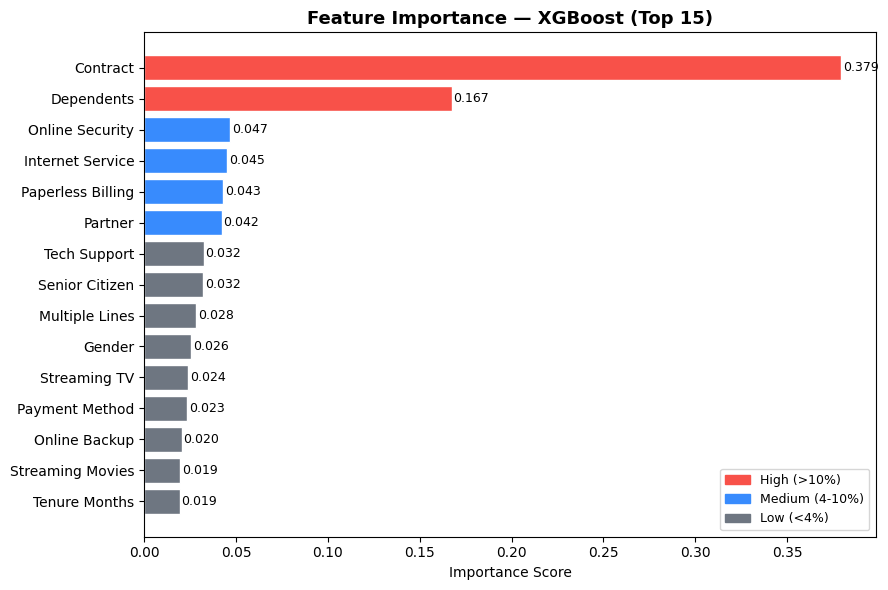


Top 10 Features:
          Feature  Importance
         Contract    0.379344
       Dependents    0.167394
  Online Security    0.046595
 Internet Service    0.045160
Paperless Billing    0.042833
          Partner    0.042092
     Tech Support    0.032430
   Senior Citizen    0.032222
   Multiple Lines    0.028209
           Gender    0.025504


In [ ]:
xgb_model = results['XGBoost']['model']
fi = xgb_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': fi})
fi_df = fi_df.sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(9, 6))
colors_fi = ['#f85149' if x > 0.10 else '#388bfd' if x > 0.04 else '#6e7681'
             for x in fi_df['Importance']]
bars = plt.barh(fi_df['Feature'], fi_df['Importance'],
                color=colors_fi, edgecolor='white')
plt.title('Feature Importance — XGBoost (Top 15)', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
for bar, v in zip(bars, fi_df['Importance']):
    plt.text(v+0.001, bar.get_y()+bar.get_height()/2,
             f'{v:.3f}', va='center', fontsize=9)

red_p  = mpatches.Patch(color='#f85149', label='High (>10%)')
blue_p = mpatches.Patch(color='#388bfd', label='Medium (4-10%)')
gray_p = mpatches.Patch(color='#6e7681', label='Low (<4%)')
plt.legend(handles=[red_p, blue_p, gray_p], fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Features:")
print(fi_df.sort_values('Importance', ascending=False)
           .head(10).to_string(index=False))

In [ ]:
def predict_customer(customer_id: str) -> None:
    """Predict churn probability for one customer by CustomerID."""
    row = df[df['CustomerID'] == customer_id]
    if row.empty:
        print(f"❌ CustomerID '{customer_id}' not found.")
        return

    row_enc = df_enc.loc[row.index]
    prob    = float(xgb_model.predict_proba(row_enc.values)[0, 1])
    pred    = int(prob >= best_thresh)
    raw     = row.iloc[0]

    risk = ("🔴 HIGH"   if prob >= 0.70 else
            "🟡 MEDIUM" if prob >= 0.40 else "🟢 LOW")

    # Risk factors
    factors = []
    if raw.get('Contract')         == 'Month-to-month': factors.append("⚠ Month-to-month contract")
    if raw.get('Internet Service') == 'Fiber optic':    factors.append("⚠ Fiber optic internet")
    if raw.get('Online Security')  == 'No':             factors.append("⚠ No online security")
    if raw.get('Tech Support')     == 'No':             factors.append("⚠ No tech support")
    if raw.get('Payment Method')   == 'Electronic check': factors.append("⚠ Electronic check payment")
    if raw.get('Tenure Months', 99) < 12:               factors.append(f"⚠ Short tenure ({raw.get('Tenure Months')} months)")
    if raw.get('Senior Citizen', 0) == 1:               factors.append("⚠ Senior citizen")
    if not factors:                                     factors.append("✅ No major risk factors")

    # Advice
    advice = []
    if raw.get('Contract')        == 'Month-to-month':  advice.append("→ Offer discounted annual contract")
    if raw.get('Online Security') == 'No':              advice.append("→ Free 3-month online security trial")
    if raw.get('Tech Support')    == 'No':              advice.append("→ Bundle tech support at reduced rate")
    if raw.get('Payment Method')  == 'Electronic check': advice.append("→ Incentivize switch to auto-pay")
    if raw.get('Tenure Months', 99) < 12:               advice.append("→ Enroll in loyalty program")
    if prob >= 0.60:                                    advice.append("→ Flag for proactive retention call")
    if not advice:                                      advice.append("→ Continue standard engagement")

    print("=" * 54)
    print("  CHURN PREDICTION REPORT")
    print("=" * 54)
    print(f"  Customer ID        : {customer_id}")
    print(f"  Churn Probability  : {prob*100:.1f}%")
    print(f"  Risk Level         : {risk}")
    print(f"  Prediction         : {'⚡ WILL CHURN' if pred else '✅ WILL STAY'}")
    print(f"  Decision Threshold : {best_thresh:.2f}")
    print("-" * 54)
    print("  Customer Profile:")
    for col in ['Contract','Internet Service','Tenure Months',
                'Monthly Charges','Tech Support','Online Security',
                'Payment Method','Churn Label']:
        if col in raw.index:
            print(f"    {col:<22}: {raw[col]}")
    print("-" * 54)
    print("  Key Risk Factors:")
    for f in factors: print(f"    {f}")
    print("  Retention Advice:")
    for a in advice:  print(f"    {a}")
    print("=" * 54)

    # Gauge bar
    fig, ax = plt.subplots(figsize=(7, 1.2))
    ax.barh(['Risk'], [1], color='#e9ecef', height=0.5)
    color = '#f85149' if prob>=0.70 else ('#d29922' if prob>=0.40 else '#3fb950')
    ax.barh(['Risk'], [prob], color=color, height=0.5)
    ax.set_xlim(0, 1)
    ax.set_xticks([0, .25, .50, .75, 1])
    ax.set_xticklabels(['0%','25%','50%','75%','100%'])
    ax.set_title(f'{customer_id} — Churn Probability: {prob*100:.1f}%', fontweight='bold')
    ax.axvline(best_thresh, color='orange', lw=1.5, ls='--',
               label=f'Threshold {best_thresh:.2f}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

  CHURN PREDICTION REPORT
  Customer ID        : 7590-VHVEG
  Churn Probability  : 71.3%
  Risk Level         : 🔴 HIGH
  Prediction         : ⚡ WILL CHURN
  Decision Threshold : 0.10
------------------------------------------------------
  Customer Profile:
    Contract              : Month-to-month
    Internet Service      : DSL
    Tenure Months         : 1
    Monthly Charges       : 29.85
    Tech Support          : No
    Online Security       : No
    Payment Method        : Electronic check
    Churn Label           : No
------------------------------------------------------
  Key Risk Factors:
    ⚠ Month-to-month contract
    ⚠ No online security
    ⚠ No tech support
    ⚠ Electronic check payment
    ⚠ Short tenure (1 months)
  Retention Advice:
    → Offer discounted annual contract
    → Free 3-month online security trial
    → Bundle tech support at reduced rate
    → Incentivize switch to auto-pay
    → Enroll in loyalty program
    → Flag for proactive retention call


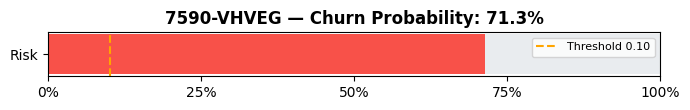

In [ ]:
predict_customer('7590-VHVEG')
